In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [ ]:
go = pd.read_csv("./data/dge_exp_vs_single_go_corrected.csv")
kegg = pd.read_csv("./data/dge_exp_vs_single_kegg_corrected.csv")

In [3]:
kegg = kegg.rename(columns={'Unnamed: 0':'ID'})
go = go.rename(columns={'Unnamed: 0':'ID'})

In [6]:
go

,ID,Term,Ont,N,DE,P.DE
0,GO:0008150,biological_process,BP,18903,37,0.920166
1,GO:0000003,reproduction,BP,1500,5,0.197671
2,GO:0001553,luteinization,BP,12,0,1.000000
3,GO:0001867,complement activation_ lectin pathway,BP,12,0,1.000000
4,GO:0001868,regulation of complement activation_ lectin pa...,BP,2,0,1.000000
...,...,...,...,...,...,...
22958,GO:0051990,(R)-2-hydroxyglutarate dehydrogenase activity,MF,1,0,1.000000
22959,GO:0047349,D-ribitol-5-phosphate cytidylyltransferase act...,MF,1,0,1.000000
22960,GO:0047613,aconitate decarboxylase activity,MF,1,0,1.000000
22961,GO:0050337,thiosulfate-thiol sulfurtransferase activity,MF,1,0,1.000000


In [ ]:
def plot_pathway_dotplot(
    df,
    pval_col='P.DE',
    de_col='DE',
    n_col='N',
    pathway_col='Term',
    top_n=20,
    save_path=None
):
    """
    Dot plot for pathway analysis:
    - x axis: rank by DE count (1 = smallest DE, top right = highest DE)
    - y axis: pathway names
    - dot size: ratio DE/N
    - color: raw p-value (P.DE)
    """

    # Calculate ratio DE/N
    df['ratio_DE_N'] = df[de_col] / df[n_col]

    # Select top pathways by pvalue descending
    df_top = df.sort_values(pval_col).head(top_n).copy()

    # Assign rank by DE count ascending (smallest rank = smallest DE)
    df_top = df_top.sort_values(de_col, ascending=True)

    # Make pathway categorical for proper y axis ordering (top = highest DE)
    df_top[pathway_col] = pd.Categorical(df_top[pathway_col], categories=df_top[pathway_col], ordered=True)

    plt.figure(figsize=(17, 10))
    scatter = plt.scatter(
        x=df_top['DE'],
        y=df_top[pathway_col],
        s=300, # Adjust size scaling here
        c=df_top[pval_col],
        cmap='viridis_r',
        edgecolors='black',
        alpha=0.8
    )

    # Format colorbar ticks to show raw p-values nicely
    cbar = plt.colorbar(scatter, fraction=0.03, pad=0.04)
    cbar.set_label('p-value')
    cbar.ax.tick_params(labelsize=18)    # increase tick label size
    cbar.ax.yaxis.label.set_size(20)     # increase colorbar title size


    formatter = FuncFormatter(lambda x, pos: f"{x:.1e}")
    cbar.ax.yaxis.set_major_formatter(formatter)

    # X axis - ranks but label by DE count values for clarity
    plt.xticks(ticks=df_top['DE'], labels=df_top[de_col], rotation=45)
    plt.xlabel('Number of DE Genes',size=18)
    plt.ylabel('')
    plt.title(f'Top {top_n} Pathways',size=20)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Increase the font size of pathway names
    plt.yticks(fontsize=18)  # Adjust the font size as needed
    plt.xticks(fontsize=16)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600)

    plt.show()


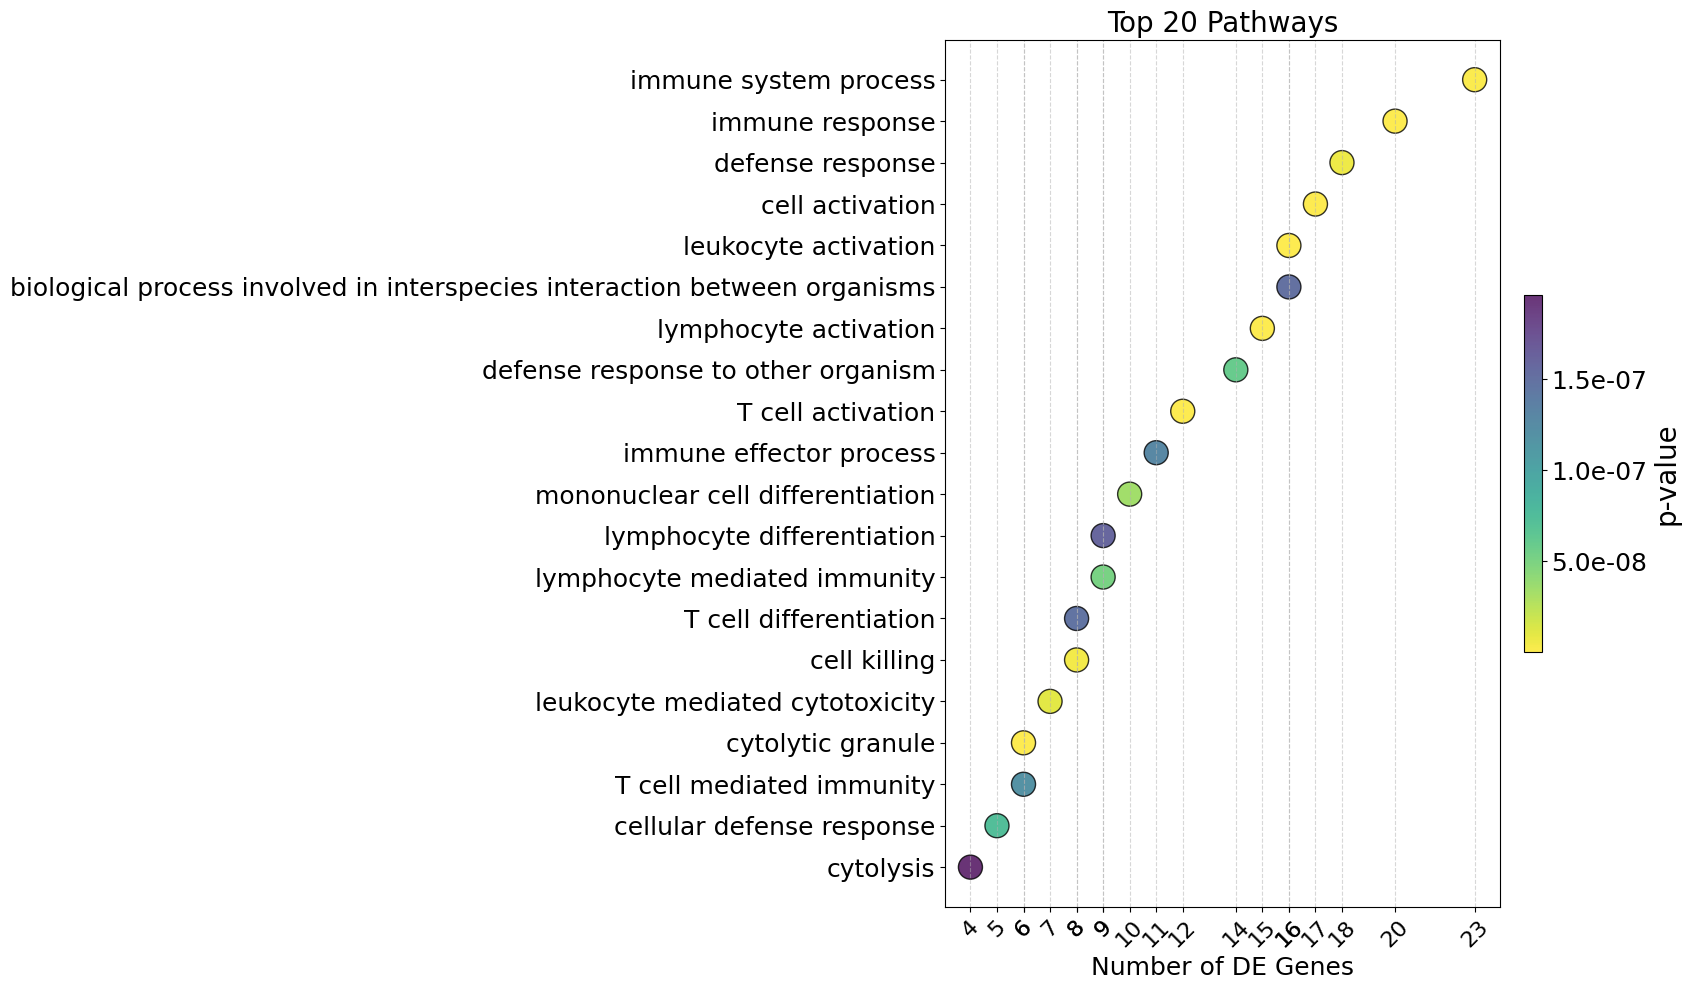

In [32]:
plot_pathway_dotplot(go,save_path='./figures/article/top20_go.png')

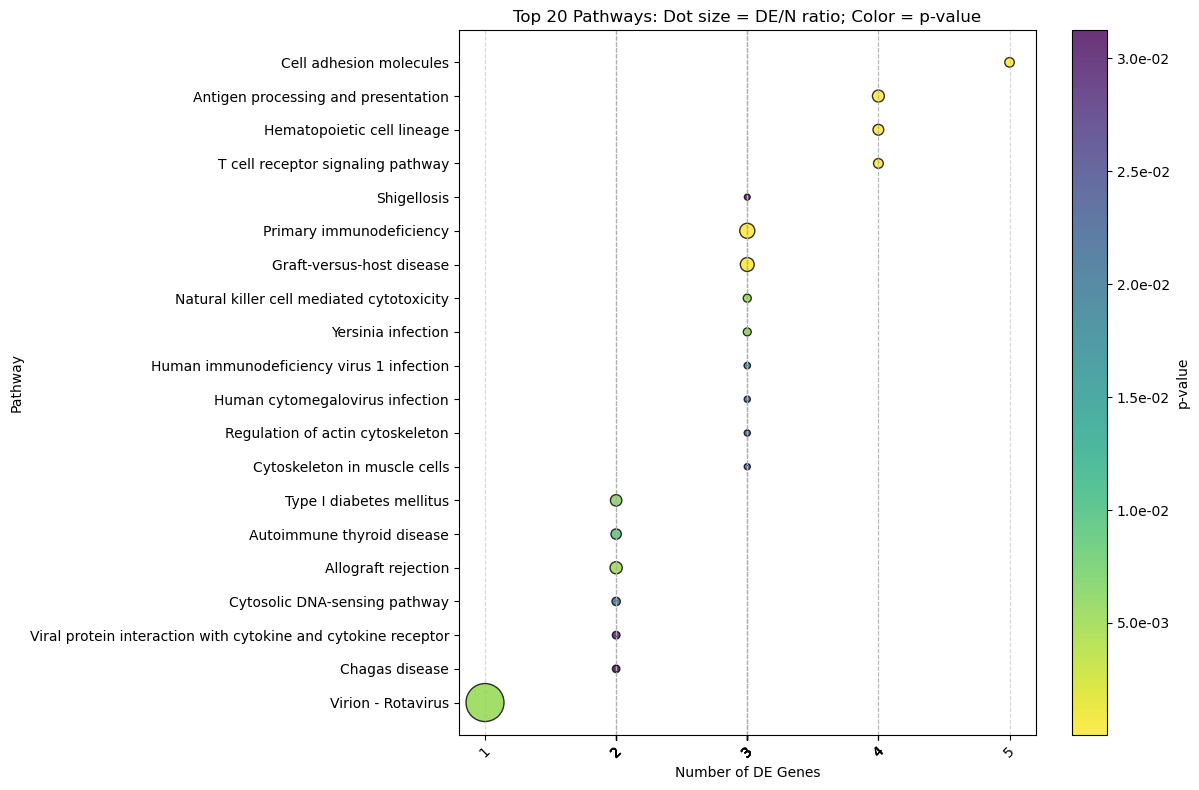

In [60]:
plot_pathway_dotplot(kegg,pathway_col='Pathway',save_path='./figures/pathways/top20_kegg.png')